In [1]:
#import 
from matplotlib import (pyplot as plt, patches, colors as mplCol)
import numpy as np
import pandas as pd
from astropy.coordinates import (SkyCoord, Distance, Galactic)
from astropy import (table, units as u)
from read_mist_models import ISOCMD
import scipy

from astroquery.gaia import Gaia


In [2]:
#three color plots
fun_3col = {'contrast_plt': ['#7321bd', '#b62746', '#c59800']
           'metallicity_standard': ['darkmagenta','green','darkcyan']}

In [3]:
#Read get gaia tables
file = r'../files/photometric_datav4.csv'
full_data = pd.read_csv(file)
print(full_data.columns.to_list())
print(len(full_data))

['star', '2MASS ID', 'Gaia DR3 ID', 'AllWISE ID', 'GALEX ID', 'ra', 'dec', 'distance', 'vsini', 'VSX Period', 'Av', 'fe_h', 'm_G', 'Gaia G flux_over_error', 'm_BP', 'Gaia BP flux_over_error', 'm_RP', 'Gaia RP flux_over_error', '2MASS J', '2MASS J error', '2MASS H', '2MASS H error', '2MASS K', '2MASS K error', 'WISE W1', 'WISE W1 error', 'WISE W2', 'WISE W2 error', 'WISE W3', 'WISE W3 error', 'WISE W4', 'WISE W4 error', 'GALEX FUV', 'GALEX FUV Error', 'GALEX NUV', 'GALEX NUV Error', 'Li Profile', 'H-alpha Profile', 'Ca II H Profile', 'Ca II K Profile', '2MASS_qph', 'ALLWISE_ccf', 'ALLWISE_qph', 'leiner_class', 'updated_class']
1895


In [4]:
#Rename 
gaia_ids = str(list(full_data['Gaia DR3 ID'])).strip('[]') #get gaia ids

#Remove gaia photometry
full_data_concat = full_data[['star',  '2MASS ID','Gaia DR3 ID', 'AllWISE ID', 'vsini', 'VSX Period', 'Av', 
                      '2MASS J', '2MASS J error', '2MASS H', '2MASS H error', '2MASS K', '2MASS K error', 
                     'WISE W1', 'WISE W1 error', 'WISE W2', 'WISE W2 error', 'WISE W3', 'WISE W3 error', 
                     'WISE W4', 'WISE W4 error', 'Li Profile', 'H-alpha Profile', 
                     'Ca II H Profile', 'Ca II K Profile', '2MASS_qph','ALLWISE_ccf', 'ALLWISE_qph', 'updated_class']]
#rename column
full_data_concat = full_data_concat.rename(columns={'Gaia DR3 ID': 'source_id'})
#convert to astropy
ffull_data_concat = table.Table.from_pandas(full_data_concat)

In [5]:
#gaia query
query_text = f'''SELECT TOP 3000 subquery.source_id, ra, dec, bp_rp, phot_g_mean_mag, 
mh_gspphot, parallax, pmra, pmdec, ruwe, galex.*
FROM (
  SELECT gaia.*, EPOCH_PROP_POS(ra, dec, parallax, pmra, pmdec, radial_velocity, ref_epoch, 2000) AS propagated_position_vector
  FROM gaiadr3.gaia_source AS gaia
  WHERE gaia.source_id IN ({gaia_ids})
  OFFSET 0) AS subquery
JOIN external.galex_ais AS galex
ON DISTANCE(COORD1(subquery.propagated_position_vector), 
COORD2(subquery.propagated_position_vector), galex.raj2000, galex.dej2000) < 3./3600.

'''



#f'''SELECT TOP 10000 *
#FROM gaiadr3.gaia_source 
#WHERE gaiadr3.gaia_source.source_id IN ({gaia_ids})'''

job = Gaia.launch_job(query_text) 
gaia_data = job.get_results()

In [6]:
print(job)

<Table length=1025>
      name       dtype    unit                                                    description                                                   n_bad
--------------- ------- -------- -------------------------------------------------------------------------------------------------------------- -----
      source_id   int64                                                      Unique source identifier (unique within a particular Data Release)     0
             ra float64      deg                                                                                                Right ascension     0
            dec float64      deg                                                                                                    Declination     0
          bp_rp float32      mag                                                                                                 BP - RP colour     0
phot_g_mean_mag float32      mag                                                

In [7]:
#join tables
gaia_data = table.join(gaia_data, ffull_data_concat, keys = 'source_id', 
                       keep_order = True, join_type= 'left')

In [8]:
gaia_data

source_id,ra,dec,bp_rp,phot_g_mean_mag,mh_gspphot,parallax,pmra,pmdec,ruwe,raj2000,dej2000,name,objid,phid,cat,rafdeg,defdeg,fuvexp,nuvexp,glon,glat,tile,img,sv,r_fov,obs,b,e_b_v,sp_,chkf,fuvmag,e_fuvmag,nuvmag,e_nuvmag,fuv_a,e_fuv_a,nuv_a,e_nuv_a,fuv_4,e_fuv_4,nuv_4,e_nuv_4,fuv_6,e_fuv_6,nuv_6,e_nuv_6,fafl,nafl,fexf,nexf,fflux,e_fflux,nflux,e_nflux,fxpos,fypos,nxpos,nypos,fima,nima,fr,nr,ns_g,fs_g,nell,fell,npa,e_npa,fpa,e_fpa,fnr,f3r,nar,narms,nbrms,far,farms,fbrms,nuvw,fuvw,prob,sep,nerr,ferr,ierr,nperr,fperr,cv,g,n,primid,groupid,gd,nd,primidd,groupidd,grouptot,oname,size,star,2MASS ID,AllWISE ID,vsini,VSX Period,Av,2MASS J,2MASS J error,2MASS H,2MASS H error,2MASS K,2MASS K error,WISE W1,WISE W1 error,WISE W2,WISE W2 error,WISE W3,WISE W3 error,WISE W4,WISE W4 error,Li Profile,H-alpha Profile,Ca II H Profile,Ca II K Profile,2MASS_qph,ALLWISE_ccf,ALLWISE_qph,updated_class
,deg,deg,mag,mag,dex,mas,mas / yr,mas / yr,,deg,deg,NULL,NULL,NULL,NULL,deg,deg,s,s,deg,deg,NULL,NULL,NULL,deg,NULL,NULL,mag,NULL,NULL,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,NULL,NULL,NULL,NULL,uJy,uJy,uJy,uJy,pix,pix,pix,pix,pix,pix,deg,deg,NULL,NULL,NULL,NULL,deg,deg,deg,deg,pix,pix,NULL,deg,deg,NULL,deg,deg,s,s,NULL,arcsec,arcsec,arcsec,arcsec,arcsec,arcsec,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,pix,,,,,,,,,,,,,,,,,,,,,,,,,,,,
int64,float64,float64,float32,float32,float32,float64,float64,float64,float32,float64,float64,str22,int64,int64,str3,float64,float64,float32,float32,float64,float64,int32,int16,int16,float64,int16,int16,float32,int16,int16,float32,float32,float32,float32,float32,float32,float64,float32,float32,float64,float32,float64,float32,float64,float32,float64,int16,int16,int16,int16,float64,float64,float64,float64,float32,float32,float32,float32,float64,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float32,float32,float64,float32,float32,float32,float32,float32,float32,object,int16,int16,int64,str239,int16,int16,int64,str239,str239,str31,float64,str28,str22,str25,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str3,str16,str18,str18,str3,str4,str4,str3
630652248758302720,141.37056136203498,15.33946465526396,1.397294,14.820238,-0.2803,0.519274780328688,-5.21031040464658,-0.3116868341025802,1.3966999,141.370928,15.339788,GALEX J092529.0+152023,6377741552664449264,6377741552663396352,AIS,141.140209,14.95927,211.15,211.15,215.8431,40.9239,50194,865,27,0.440896,1,1,0.0268,0,0,--,--,21.5764,0.2282,--,--,1.4964,0.2282,--,--,1.6015,0.223,--,--,1.8047,0.4237,0,1,0,0,--,--,8.50002,1.78594,--,--,1384.38,2837.24,--,5.346,--,0.002,0.9806,0.0,0.0474,--,-9.74,2.79,--,--,9.06989956,3.29387999,3.5,0.000647,0.000616,--,--,--,173.3,181.5,--,--,0.86,--,--,0.36,--,C,1,2,6377741552664449024,6377741552664449264+6377741405662478694,1,2,6377741552664449024,6377741552664449264+6377741405662478694,6377741552664449264+6377741405662478694,N,0.0,ZTF J092528.93+152022.1,2MASS 09252893+1520221,WISEA J092528.93+152022.0,--,3.67,0.07,12.877,0.023,12.298,0.025,12.139,0.022,12.065,0.023,12.057,0.023,11.751,0.265,8.916,--,--,--,--,--,AAA,0000,AABU,SSG
630652248758302720,141.37056136203498,15.33946465526396,1.397294,14.820238,-0.2803,0.519274780328688,-5.21031040464658,-0.3116868341025802,1.3966999,141.370093,15.339448,GALEX J092528.8+152022,6377741405628924166,6377741405627875328,AIS,141.665213,15.80441,62.9,62.9,215.8431,40.923,50194,579,18,0.544985,1,1,0.0268,0,0,--,--,21.5695,0.4424,--,--,1.4895,0.4424,--,--,1.5188,0.464,--,--,2.0454,1.2798,0,0,0,0,--,--,8.55428,3.48451,--,--,2668.69,855.77,--,3.992,--,0.002,0.9703,0.0,0.3053,--,2.8,1.99,--,--,0.0,62.6200981,3.5,0.000568,0.000395,--,--,--,47.2,31.5,--,--,1.1,--,--,0.43,--,V,-1,2,6377741405628923904,6377741405628924166,-1,1,6377741405628923904,6377741405628924166,6377741405662478694+63777414056

In [9]:
#RAW Magnitudes
m_G = np.array(gaia_data['phot_g_mean_mag'], dtype = float)
uncor_nuv = np.array(gaia_data['nuvmag'], dtype =float)
uncor_fuv = np.array(gaia_data['fuvmag'], dtype = float) 

#Reddening
av = np.array(gaia_data['Av'], dtype = float)
ag_gaia = av*0.789
Ebp_rp = ag_gaia/1.890 #ag/e(bp=rp) = 1.890
E_FUV_NUV = -2.35*(av/3.1) #cite https://academic.oup.com/mnras/article/430/3/2188/981583#26020373
#Color Corr
#R(a) × E(B − V) 
fuv = uncor_fuv - 2.68 *av #4.89 * (av/3.1)
nuv = uncor_nuv - av * 2.63 # 7.24 * (av/3.1) #https://academic.oup.com/mnras/article/489/4/5046/5565069
k_mag = np.array(gaia_data['2MASS K'], dtype=float) - 0.078*av #https://iopscience.iop.org/article/10.3847/1538-4357/ab1c61
j_mag = np.array(gaia_data['2MASS J'], dtype=float) - 0.243 *av #0.243 

fuv_nuv = (uncor_fuv - uncor_nuv) - E_FUV_NUV
bp_rp =  np.array(gaia_data['bp_rp'], dtype = float)  - Ebp_rp
j_k_col = j_mag - k_mag
nuv_j = nuv - j_mag
fuv_j = fuv - j_mag

#other intermediates
dist = np.array(Distance(parallax=u.Quantity(gaia_data['parallax'])), dtype = float)

#Other
M_G = -5*np.log10(dist) + m_G - ag_gaia + 5 #m-M = 5log(d) - 5 + Av
metallicity = np.array(gaia_data['mh_gspphot'], dtype = float)
periods = np.array(gaia_data['VSX Period'], dtype = float)
vsinis = np.array(gaia_data['vsini'], dtype=float)

In [10]:
nuv_jx = 10.36*j_k_col + 2.76
E0_nuv = nuv_j - nuv_jx 

zeta_mh = 1.7815*metallicity +  0.7221
Ez_nuv = E0_nuv - zeta_mh

In [11]:
#Magnetic Line labels
ha_emis = (np.array(gaia_data['H-alpha Profile']) == 'Emission')
var_ha = (np.array(gaia_data['H-alpha Profile']) == 'Variable H-alpha')
ha_abs = (np.array(gaia_data['H-alpha Profile']) == 'Absorption')

yes_li = (np.array(gaia_data['Li Profile']) == 'Yes')
no_li = (np.array(gaia_data['Li Profile']) == 'No')

caH_emis = (np.array(gaia_data['Ca II H Profile']) == 'Normal Emission')
no_caH = (np.array(gaia_data['Ca II H Profile']) == 'None/To Noisy')
var_caH = (np.array(gaia_data['Ca II H Profile']) == 'Variable')

caK_emis = (np.array(gaia_data['Ca II K Profile']) == 'Normal Emission')
no_caK = (np.array(gaia_data['Ca II K Profile']) == 'None/To Noisy')
var_caK = (np.array(gaia_data['Ca II K Profile']) == 'Variable')

In [12]:
low_rv_var_ids = np.array([3137895792132452736,672877103038407040,4527508855614868992,
                  1494123125466322560,1605979810614504704,1489388868914750976 ,4597154602175212672])
low_rvs = np.array([True if item in low_rv_var_ids else False for item in gaia_data['source_id']])

In [13]:
j_k_ther = np.arange(0, 1.2, 0.1)
findesien_tau = 10.36*j_k_ther + 2.76
findeisen_tau_fuv = 20.5*j_k_ther + 2.96 
findesien_sco = 10.05*j_k_ther + 2.64
#Cite https://iopscience.iop.org/article/10.1088/0004-6256/139/4/1338#aj332183fd2



In [14]:

NSVS14892045 = (gaia_data['source_id'] == 3178786251609990656)
gaia_data[['star','ra', 'dec','source_id', '2MASS ID', 
           'AllWISE ID', 'pmra', 'pmdec']][NSVS14892045]

star,ra,dec,source_id,2MASS ID,AllWISE ID,pmra,pmdec
,deg,deg,,,,mas / yr,mas / yr
str28,float64,float64,int64,str22,str25,float64,float64
NSVS 14892045,64.79835918797268,-12.118952342416229,3178786251609990656,2MASS 04191159-1207082,WISEA J041911.60-120708.1,5.056866889382854,-0.9589600789551712


# Compare to  Dixon (2025)

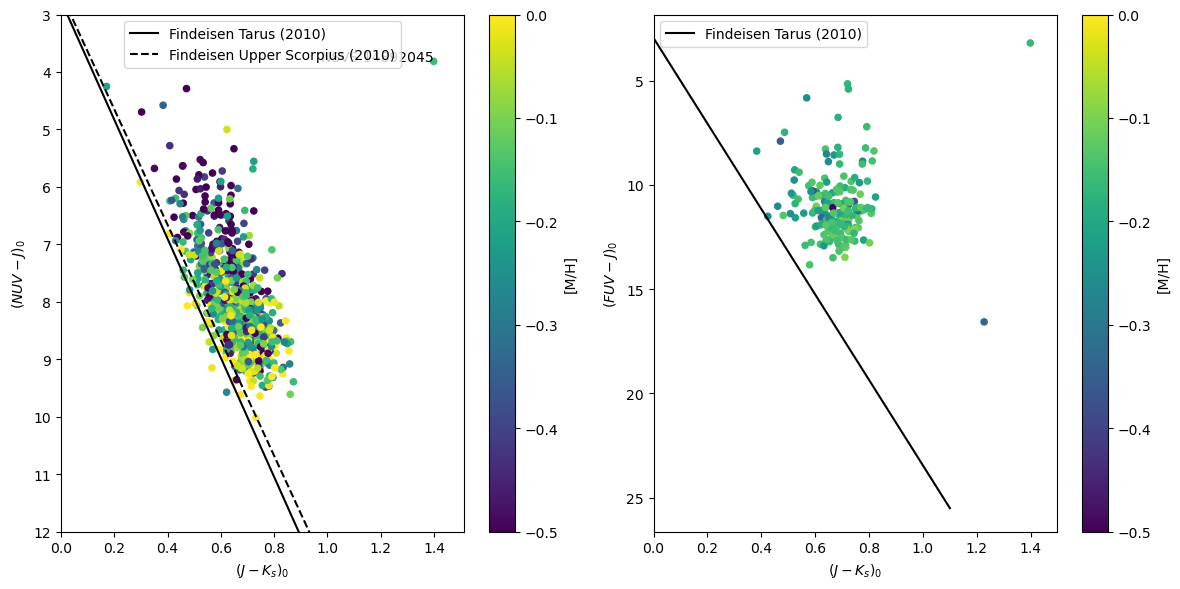

In [15]:
ha_wierd = ['left', 'left', 'right', 'right']

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12,6))
cs = ax.scatter(j_k_col, nuv_j, c=metallicity, s = 20, vmin=-0.50, vmax=0.00)
ax.plot(j_k_ther, findesien_tau, color = 'black', label = 'Findeisen Tarus (2010)')
ax.plot(j_k_ther, findesien_sco, color = 'black', label = 'Findeisen Upper Scorpius (2010)', ls = '--')
cb = fig.colorbar(cs, ax = ax)
ax.set_ylabel('$(NUV-J)_0$')
ax.set_xlabel('$(J-K_{s})_0$')
ax.set_xlim(left = 0)
ax.set_ylim(12,3)
cb.set_label('[M/H]')
ax.text(j_k_col[NSVS14892045], nuv_j[NSVS14892045], 'NSVS 14892045', ha = 'right')
ax.legend()

cs2 = ax2.scatter(j_k_col, fuv_j, c=metallicity, s = 20, vmin=-1.50, vmax=0.50)
cb2 = fig.colorbar(cs, ax = ax2)
ax2.plot(j_k_ther, findeisen_tau_fuv, color = 'black', label = 'Findeisen Tarus (2010)')
ax2.set_ylabel('$(FUV-J)_0$')
ax2.set_xlabel('$(J-K_{s})_0$')
ax2.set_xlim(left=0)
ax2.invert_yaxis()
cb2.set_label('[M/H]')
fig.tight_layout()

ax2.legend()

#look at outliers later

## Compare to T-Tauris
https://www.aanda.org/articles/aa/full_html/2024/01/aa45871-23/aa45871-23.html

In [16]:
t_tau_file = r'../files/t_tauri_table2.csv'
t_tau_dat = pd.read_csv(t_tau_file)
print(t_tau_dat.columns.to_list())
print(len(t_tau_dat))

['source_id', '2MASS', 'AllWISE', 'GALEX', 'ra', 'dec', 'pmra', 'pmdec', 'distance', 'e_b_v', 'mh_gspphot', 'ruwe', 'phot_g_mean_mag', 'phot_g_mean_flux_over_error', 'phot_bp_mean_mag', 'phot_bp_mean_flux_over_error', 'phot_rp_mean_mag', 'phot_rp_mean_flux_over_error', 'Jmag', 'e_Jmag', 'Hmag', 'e_Hmag', 'Kmag', 'e_Kmag', 'W1mag', 'e_W1mag', 'W2mag', 'e_W2mag', 'W3mag', 'e_W3mag', 'W4mag', 'e_W4mag', 'fuvmag', 'e_fuvmag', 'nuvmag', 'e_nuvmag', '2MASS_qph', 'AllWISE_ccf', 'AllWISE_qph', 'accretion', 'bp_rp_0', 'fuv_j_0', 'nuv_j_0', 'fuv_nuv_0', 'j_k_0']
168


(0.0, 2.5)

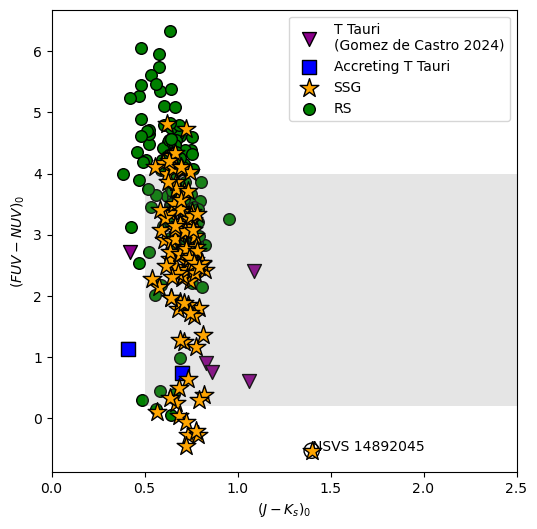

In [17]:
name = ((j_k_col <0) & (fuv >-999))
accret_ttau = (t_tau_dat['accretion'] == True)
ssgs = (np.array(gaia_data['updated_class']) == 'SSG')
RS = (np.array(gaia_data['updated_class']) == 'RS')

#General Range T Tauris
rect= patches.Rectangle((0.5, 0.2), 2, 3.8, 
                        #fill=False,
                        alpha=0.2,
                        #color="turquoise",
                       #linewidth=2,
                       facecolor= 'grey')
                      # label = 'T Tauri Range')#"darkturquoise")



#Plot Figure
fig, ax = plt.subplots(1, 1, figsize=(6,6))

ax.scatter(t_tau_dat['j_k_0'], t_tau_dat['fuv_nuv_0'], label = 'T Tauri \n(Gomez de Castro 2024)',
          marker = 'v', color = 'darkmagenta', edgecolor='black', s=100)
ax.scatter(t_tau_dat['j_k_0'][accret_ttau], t_tau_dat['fuv_nuv_0'][accret_ttau], 
           label = 'Accreting T Tauri',
          marker = 's', color = 'blue', edgecolor='black', s=100, zorder=9)

ax.scatter(j_k_col[ssgs], fuv_nuv[ssgs], c='orange', s = 200, 
           label = 'SSG', edgecolor='black', marker = '*', zorder=9)
ax.scatter(j_k_col[RS], fuv_nuv[RS], c='Green', s = 70,#  vmin=2, vmax=30, 
           label = 'RS', edgecolor='black', marker='o')

ax.set_ylabel('$(FUV-NUV)_0$')
ax.set_xlabel('$(J-K_{s})_0$')
ax.legend()
ax.scatter(j_k_col[NSVS14892045], fuv_nuv[NSVS14892045], color = 'None',
           s = 120, edgecolor='black', marker='o')
ax.text(j_k_col[NSVS14892045], fuv_nuv[NSVS14892045], 'NSVS 14892045', ha ='left')
#ax.text(j_k_col[name], fuv_nuv[name], gaia_data['star'][name][0], ha ='left')
plt.gca().add_patch(rect)
ax.legend()

del name
ax.set_xlim(0, 2.5)
#ax.set_ylim(12,3)
#cb.set_label('$P_{VSX}$')

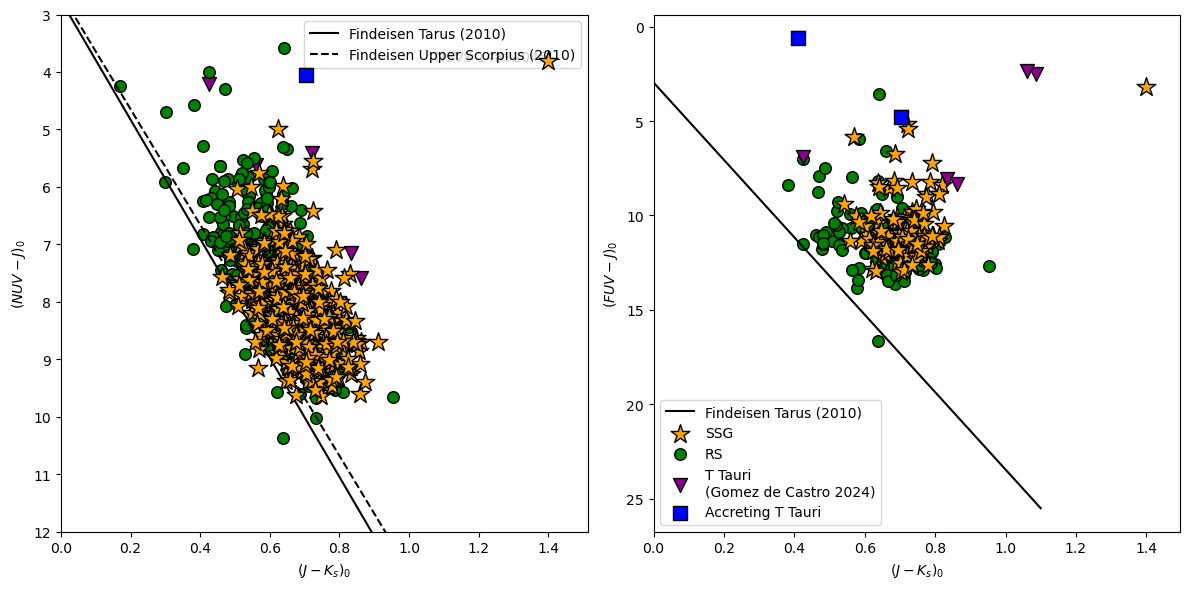

In [18]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12,6))
ax.plot(j_k_ther, findesien_tau, color = 'black', label = 'Findeisen Tarus (2010)')
ax.plot(j_k_ther, findesien_sco, color = 'black', label = 'Findeisen Upper Scorpius (2010)', ls = '--')

ax.scatter(t_tau_dat['j_k_0'], t_tau_dat['nuv_j_0'], #label = 'T Tauri \n(Gomez de Castro 2024)',
          marker = 'v', color = 'darkmagenta', edgecolor='black', s=100)
ax.scatter(t_tau_dat['j_k_0'][accret_ttau], t_tau_dat['nuv_j_0'][accret_ttau], 
           #label = 'Accreting T Tauri',
          marker = 's', color = 'blue', edgecolor='black', s=100, zorder=9)

ax.scatter(j_k_col[ssgs], nuv_j[ssgs], c='orange', s = 200, 
           #label = 'SSG', 
           edgecolor='black', marker = '*', zorder=9)
ax.scatter(j_k_col[RS], nuv_j[RS], c='Green', s = 70,#  vmin=2, vmax=30, 
           #label = 'RS', 
           edgecolor='black', marker='o')

ax.set_ylabel('$(NUV-J)_0$')
ax.set_xlabel('$(J-K_{s})_0$')
ax.set_xlim(left = 0)
ax.set_ylim(12,3)
ax.text(j_k_col[NSVS14892045], nuv_j[NSVS14892045], 'NSVS 14892045', ha = 'right')
ax.legend()

ax2.plot(j_k_ther, findeisen_tau_fuv, color = 'black', label = 'Findeisen Tarus (2010)')

ax2.scatter(j_k_col[ssgs], fuv_j[ssgs], c='orange', s = 200, label = 'SSG', 
           edgecolor='black', marker = '*', zorder=8)
ax2.scatter(j_k_col[RS], fuv_j[RS], c='Green', s = 70, label = 'RS',
           edgecolor='black', marker='o')
ax2.scatter(t_tau_dat['j_k_0'], t_tau_dat['fuv_j_0'], label = 'T Tauri \n(Gomez de Castro 2024)',
          marker = 'v', color = 'darkmagenta', edgecolor='black', s=100, zorder=9)
ax2.scatter(t_tau_dat['j_k_0'][accret_ttau], t_tau_dat['fuv_j_0'][accret_ttau], 
           label = 'Accreting T Tauri',
          marker = 's', color = 'blue', edgecolor='black', s=100, zorder=10)



ax2.set_ylabel('$(FUV-J)_0$')
ax2.set_xlabel('$(J-K_{s})_0$')
ax2.set_xlim(left=0)
ax2.invert_yaxis()
ax2.legend()
fig.tight_layout()


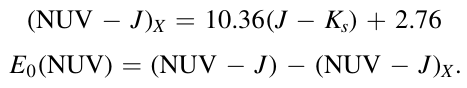

# Color-Color Diagram

In [25]:
#T_Tauri WISE Colors
av_ttau = np.array(t_tau_dat['e_b_v'])*3.1
w1 = np.array(t_tau_dat['W1mag'], dtype = float) - av_ttau * 0.039 
w2 = np.array(t_tau_dat['W2mag'], dtype = float) - av_ttau * 0.039 
w3 = np.array(t_tau_dat['W3mag'], dtype = float)  - av_ttau * 0.040 
w4 = np.array(t_tau_dat['W4mag'], dtype = float)

t_tau_dat['w1_w2'] = w1 - w2
t_tau_dat['w1_w3'] = w1 - w3
t_tau_dat['w1_w4'] = w1 - w4
t_tau_dat['w2_w3'] = w2 - w3
t_tau_dat['w2_w4'] = w2 - w4
t_tau_dat['w3_w4'] = w3 - w4
t_tau_dat['M_G'] = -5*np.log10(t_tau_dat['distance']) + t_tau_dat['phot_g_mean_mag'] -  av_ttau * 0.789 + 5 #m-M = 5log(d) - 5 + Av
del w1, w2, w3, w4, av_ttau

tau_phot_qual = np.array([False if len(str(item)) != 4 else False if ((str(item)[1] == 'U') or (str(item)[2] == 'U')
                                                                or (str(item)[0] == 'U') or (str(item)[3] == 'U'))
                      else True for item in t_tau_dat['AllWISE_qph']])
no_flag_ttau = (t_tau_dat['AllWISE_ccf'] == '0000')

ttauri_dat2 = t_tau_dat[no_flag_ttau & tau_phot_qual]
accret_ttau2 = (ttauri_dat2['accretion'] == True)

del no_flag_ttau, tau_phot_qual

In [20]:
#SSG WISE colors
w1 = np.array(gaia_data['WISE W1'], dtype = float) - av * 0.039 
w2 = np.array(gaia_data['WISE W2'], dtype = float) - av * 0.039 
w3 = np.array(gaia_data['WISE W3'], dtype = float)  - av * 0.040 
w4 = np.array(gaia_data['WISE W4'], dtype = float)


w1_w2 = w1 - w2
w1_w3 = w1 - w3
w1_w4 = w1 - w4
w2_w3 = w2 - w3
w2_w4 = w2 - w4
w3_w4 = w3 - w4

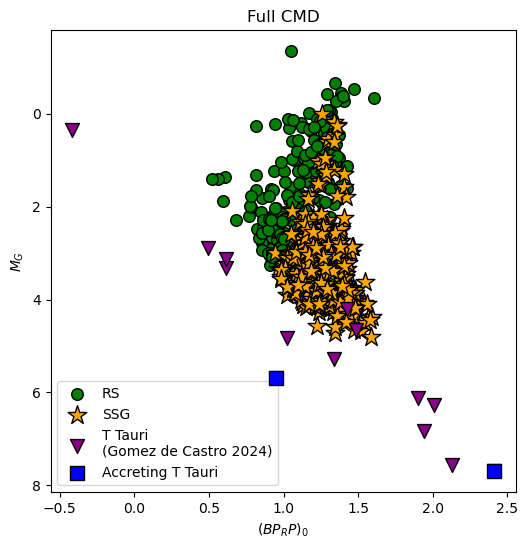

In [32]:
fig, ax = plt.subplots(1, figsize=(6, 6))
    
#full Sample
ax.set_title('Full CMD')
ax.scatter(bp_rp[RS], M_G[RS], c='Green', s = 70,#  vmin=2, vmax=30, 
               label = 'RS', edgecolor='black', marker='o')

ax.scatter(bp_rp[ssgs], M_G[ssgs], c='orange', s = 200, 
           label = 'SSG', edgecolor='black', marker = '*', zorder=8)
ax.scatter(t_tau_dat['bp_rp_0'], t_tau_dat['M_G'], label = 'T Tauri \n(Gomez de Castro 2024)',
          marker = 'v', color = 'darkmagenta', edgecolor='black', s=100, zorder=10)
ax.scatter(t_tau_dat['bp_rp_0'][accret_ttau], t_tau_dat['M_G'][accret_ttau], 
           label = 'Accreting T Tauri',
          marker = 's', color = 'blue', edgecolor='black', s=100, zorder=10)


#ax.set_xlim(0, 2.60)
#ax.set_ylim(-2.5,6.5)
ax.invert_yaxis()
ax.set_xlabel('$(BP_RP)_0$')
ax.set_ylabel('$M_G$')
ax.legend()

In [21]:
#check fo WISE photometric quality
phot_qual = np.array([False if len(str(item)) != 4 else True if ((str(item)[1] == 'U') or (str(item)[2] == 'U')
                                                                or (str(item)[0] == 'U') or (str(item)[3] == 'U'))
                      else False for item in gaia_data['ALLWISE_qph']])
# ccf_data is good
no_flag = ((gaia_data['ALLWISE_ccf'] == '0000') & (phot_qual == False))

[ True  True  True ...  True  True  True]
[ True  True  True ...  True False False]


In [22]:
unusual = ((w1_w2 > 0.4) | (w2_w3 > 1.4))

def wise_color_color(ax, wa_wb, wc_wd, ttau_ab, ttau_cd, x_label, y_label, ha = 'right'):
    ax.scatter(wa_wb[ssgs & no_flag], wc_wd[ssgs & no_flag], c='orange', s = 200, 
               label = 'SSG', 
               edgecolor='black', marker = '*', zorder=8)
    ax.scatter(wa_wb[RS & no_flag], wc_wd[RS & no_flag], c='Green', s = 70,#  vmin=2, vmax=30, 
               label = 'RS', 
               edgecolor='black', marker='o')
    ax.scatter(ttauri_dat2[ttau_ab], ttauri_dat2[ttau_cd], label = 'T Tauri \n(Gomez de Castro 2024)',
              marker = 'v', color = 'darkmagenta', edgecolor='black', s=100, zorder=9)
    ax.scatter(ttauri_dat2[ttau_ab][accret_ttau2], ttauri_dat2[ttau_cd][accret_ttau2], 
               label = 'Accreting T Tauri',
              marker = 's', color = 'blue', edgecolor='black', s=100, zorder=10)
    
    for i in range(len(w2_w3[unusual & no_flag])):
        ax.text(wa_wb[unusual & no_flag][i], wc_wd[unusual & no_flag][i], 
            gaia_data['star'][unusual & no_flag][i], ha = ha, zorder=10)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

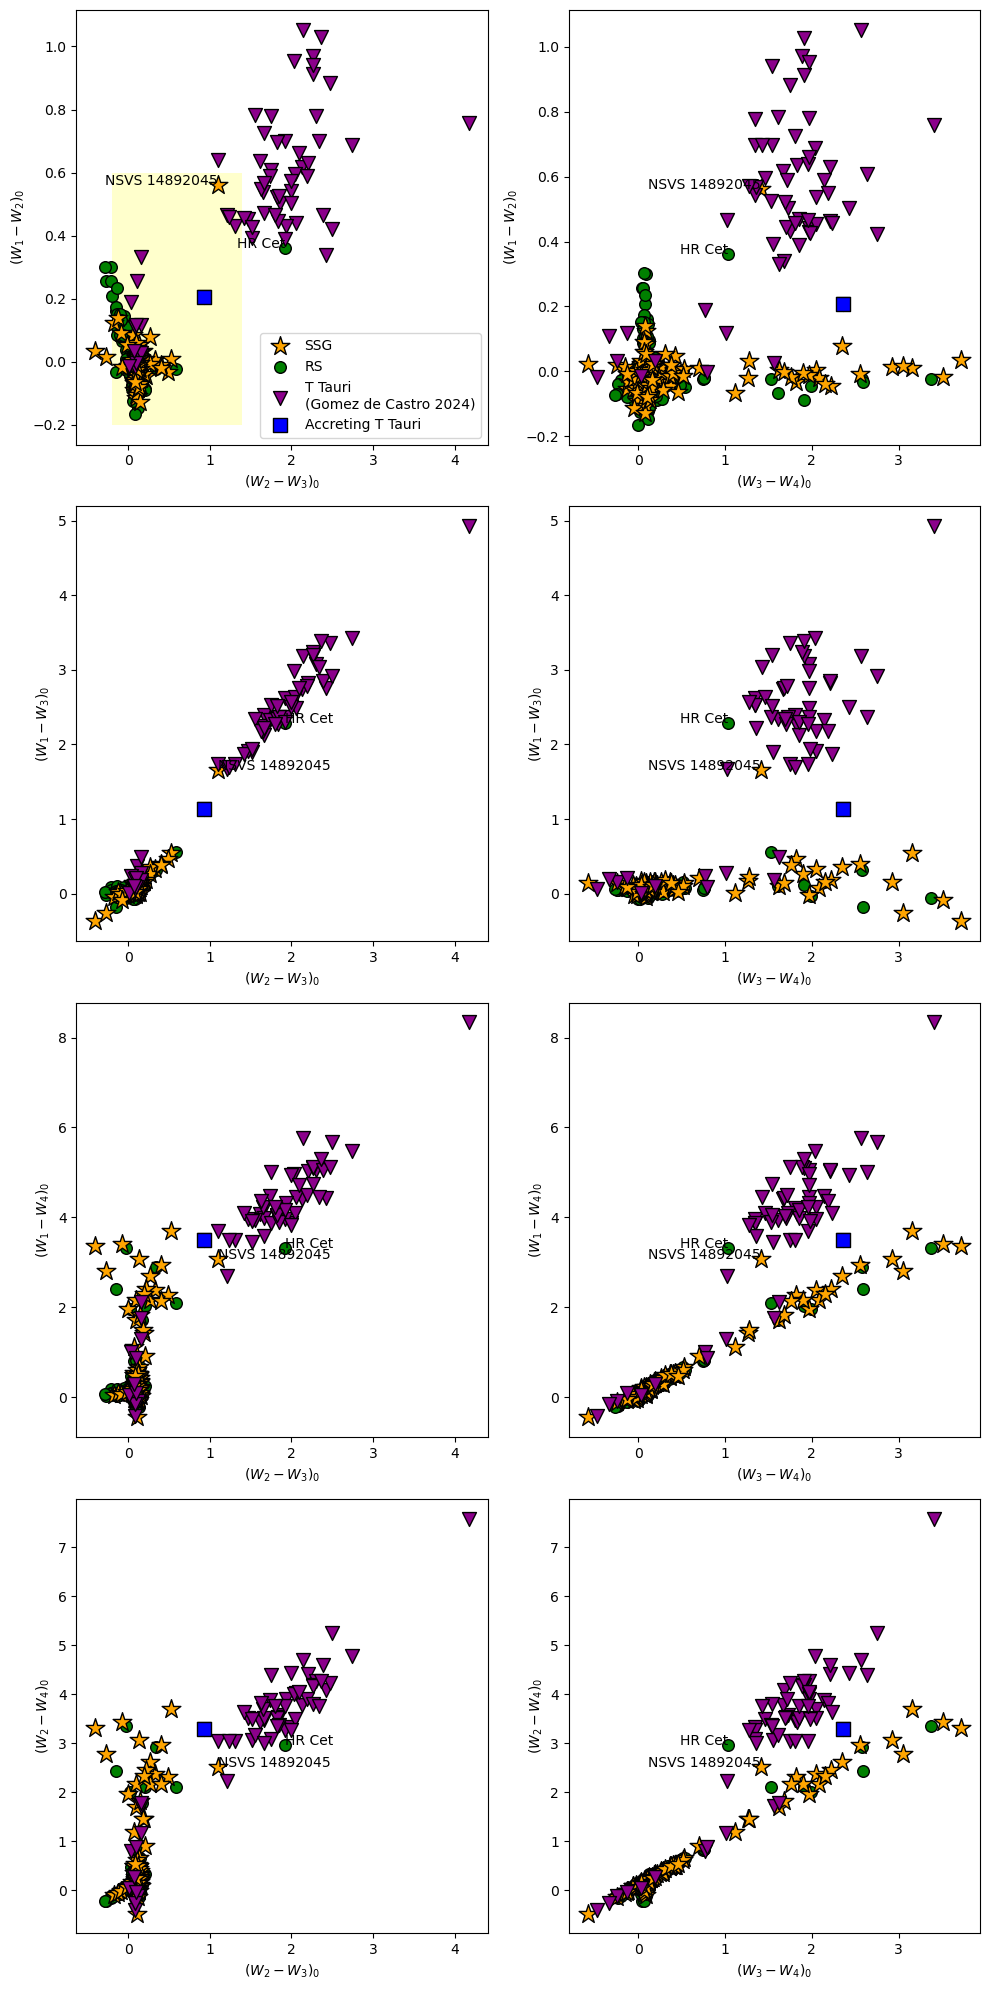

In [23]:
fig, ((ax,ax2), (ax3, ax4), 
      (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2,  figsize = (10,20))
ax.add_patch(rect)
wise_color_color(ax=ax, wa_wb=w2_w3, wc_wd=w1_w2, ttau_ab = 'w2_w3', ttau_cd='w1_w2',
                x_label='$(W_{2}-W_{3})_0$', y_label= '$(W_{1}-W_{2})_0$')
ax.legend()

wise_color_color(ax=ax2, wa_wb=w3_w4, wc_wd=w1_w2, ttau_ab = 'w3_w4', ttau_cd='w1_w2',
                x_label='$(W_{3}-W_{4})_0$', y_label= '$(W_{1}-W_{2})_0$')

wise_color_color(ax=ax3, wa_wb=w2_w3, wc_wd=w1_w3, ttau_ab = 'w2_w3', ttau_cd='w1_w3',
                x_label='$(W_{2}-W_{3})_0$', y_label= '$(W_{1}-W_{3})_0$', ha = 'left')

wise_color_color(ax=ax4, wa_wb=w3_w4, wc_wd=w1_w3, ttau_ab = 'w3_w4', ttau_cd='w1_w3',
                x_label='$(W_{3}-W_{4})_0$', y_label= '$(W_{1}-W_{3})_0$')

wise_color_color(ax=ax5, wa_wb=w2_w3, wc_wd=w1_w4, ttau_ab = 'w2_w3', ttau_cd='w1_w4',
                x_label='$(W_{2}-W_{3})_0$', y_label= '$(W_{1}-W_{4})_0$', ha = 'left')
wise_color_color(ax=ax6, wa_wb=w3_w4, wc_wd=w1_w4, ttau_ab = 'w3_w4', ttau_cd='w1_w4',
                x_label='$(W_{3}-W_{4})_0$', y_label= '$(W_{1}-W_{4})_0$')

wise_color_color(ax=ax7, wa_wb=w2_w3, wc_wd=w2_w4, ttau_ab = 'w2_w3', ttau_cd='w2_w4',
                x_label='$(W_{2}-W_{3})_0$', y_label= '$(W_{2}-W_{4})_0$', ha = 'left')

wise_color_color(ax=ax8, wa_wb=w3_w4, wc_wd=w2_w4, ttau_ab = 'w3_w4', ttau_cd='w2_w4',
                x_label='$(W_{3}-W_{4})_0$', y_label= '$(W_{2}-W_{4})_0$')

fig.tight_layout()

In [ ]:
fig, ((ax,ax2), (ax3, ax4)) = plt.subplots(2, 2,  figsize = (10,10))

#Add normal star cutoff


ax.scatter(w2_w3[ssgs & no_flag], w1_w2[ssgs & no_flag], c='orange', s = 200, 
           label = 'SSG', 
           edgecolor='black', marker = '*', zorder=9)
ax.scatter(w2_w3[RS & no_flag], w1_w2[RS & no_flag], c='Green', s = 70,#  vmin=2, vmax=30, 
           label = 'RS', 
           edgecolor='black', marker='o')
ax.scatter(t_tau_dat['w2_w3'], t_tau_dat['w1_w2'], label = 'T Tauri \n(Gomez de Castro 2024)',
          marker = 'v', color = 'darkmagenta', edgecolor='black', s=100)
ax.scatter(t_tau_dat['w2_w3'][accret_ttau], t_tau_dat['w1_w2'][accret_ttau], 
           label = 'Accreting T Tauri',
          marker = 's', color = 'blue', edgecolor='black', s=100, zorder=9)

ax.set_xlabel('$(W_{2}-W_{3})_0$')
ax.set_ylabel('$(W_{1}-W_{2})_0$')

for i in range(len(w2_w3[unusual & no_flag])):
    ax.text(w2_w3[unusual & no_flag][i], w1_w2[unusual & no_flag][i], 
            gaia_data['star'][unusual & no_flag][i], ha = 'right', zorder=10)
ax.legend()

ax2.scatter(w3_w4[ssgs & no_flag], w1_w2[ssgs & no_flag], c='orange', s = 200, 
           label = 'SSG', 
           edgecolor='black', marker = '*', zorder=9)
ax2.scatter(w3_w4[RS & no_flag], w1_w2[RS & no_flag], c='Green', s = 70,#  vmin=2, vmax=30, 
           label = 'RS', 
           edgecolor='black', marker='o')


ax2.scatter(t_tau_dat['w3_w4'], t_tau_dat['w1_w2'], label = 'T Tauri \n(Gomez de Castro 2024)',
          marker = 'v', color = 'darkmagenta', edgecolor='black', s=100)
ax2.scatter(t_tau_dat['w3_w4'][accret_ttau], t_tau_dat['w1_w2'][accret_ttau], 
           label = 'Accreting T Tauri',
          marker = 's', color = 'blue', edgecolor='black', s=100, zorder=9)


ax2.set_xlabel('$(W_{3}-W_{4})_0$')
ax2.set_ylabel('$(W_{1}-W_{2})_0$')

#label unsual stuff
for i in range(len(w3_w4[unusual & no_flag])):
    ax2.text(w3_w4[unusual & no_flag][i], w1_w2[unusual & no_flag][i], 
            gaia_data['star'][unusual & no_flag][i], ha = 'right', zorder=10)
    
    
ax3.scatter(w2_w3[ssgs & no_flag], w1_w3[ssgs & no_flag], c='orange', s = 200, 
           label = 'SSG', 
           edgecolor='black', marker = '*')
ax3.scatter(w2_w3[RS & no_flag], w1_w3[RS & no_flag], c='Green', s = 70,#  vmin=2, vmax=30, 
           label = 'RS', 
           edgecolor='black', marker='o')
ax3.scatter(t_tau_dat['w2_w3'], t_tau_dat['w1_w3'], label = 'T Tauri \n(Gomez de Castro 2024)',
          marker = 'v', color = 'darkmagenta', edgecolor='black', s=100)
ax3.scatter(t_tau_dat['w2_w3'][accret_ttau], t_tau_dat['w1_w3'][accret_ttau], 
           label = 'Accreting T Tauri',
          marker = 's', color = 'blue', edgecolor='black', s=100, zorder=9)


#ax.legend()
ax3.set_xlabel('$(W_{2}-W_{3})_0$')
ax3.set_ylabel('$(W_{1}-W_{3})_0$')


for i in range(len(w2_w3[unusual & no_flag])):
    ax3.text(w2_w3[unusual & no_flag][i], w1_w3[unusual & no_flag][i], 
            gaia_data['star'][unusual & no_flag][i], ha = 'right', zorder=10)

ax4.scatter(w3_w4[ssgs & no_flag], w1_w3[ssgs & no_flag], c='orange', s = 200, 
           label = 'SSG', 
           edgecolor='black', marker = '*')
ax4.scatter(w3_w4[RS & no_flag], w1_w3[RS & no_flag], c='Green', s = 70,#  vmin=2, vmax=30, 
           label = 'RS', 
           edgecolor='black', marker='o')
ax4.scatter(t_tau_dat['w3_w4'], t_tau_dat['w1_w3'], label = 'T Tauri \n(Gomez de Castro 2024)',
          marker = 'v', color = 'darkmagenta', edgecolor='black', s=100)
ax4.scatter(t_tau_dat['w3_w4'][accret_ttau], t_tau_dat['w1_w3'][accret_ttau], 
           label = 'Accreting T Tauri',
          marker = 's', color = 'blue', edgecolor='black', s=100, zorder=9)



for i in range(len(w3_w4[unusual & no_flag])):
    ax4.text(w3_w4[unusual & no_flag][i], w1_w3[unusual & no_flag][i], 
            gaia_data['star'][unusual & no_flag][i], ha = 'right', zorder=10)
#ax.legend()
ax4.set_xlabel('$(W_{3}-W_{4})_0$')
ax4.set_ylabel('$(W_{1}-W_{3})_0$')

fig.tight_layout()

In [ ]:
unusual = ((w1_w2 < -0.2) | (w1_w2 > 0.6) | (w2_w3 < -0.2) | (w2_w3 > 1.4))


Dra29 = (gaia_data['star'] == '29 Dra')
HUVir = (gaia_data['star'] == 'HU Vir')
FNCom = (gaia_data['star'] == 'FN Com')

fig, ax = plt.subplots(1, 1,  figsize = (5,5))

#Add normal star cutoff



ax.scatter(w2_w3[no_flag], w1_w2[no_flag],
           s = 20, color = 'grey', alpha=0.2)

ax.scatter(w2_w3[no_flag & unusual], w1_w2[no_flag & unusual],
           s = 40, marker = 'H', color = 'darkred', alpha=0.4, label='Strange AllWISE photometry')

ax.scatter(w2_w3[wierd & no_flag], w1_w2[wierd & no_flag],
           s = 40, marker = '*', color = 'blue', alpha=1, label='$(j-NUV)_0$ outliers')

ax.scatter(w2_w3[wierd & no_flag], w1_w2[wierd & no_flag],
           s = 40, marker = '*', color = 'blue', alpha=1, label='$(j-NUV)_0$ outliers')
#ha_weird = 
ha_weird = ['right', 'left', 'right']


#ax.axvline(-0.2, ls = '--', color = 'darkmagenta')
#ax.axvline(0.8, ls = '--', color = 'darkmagenta')
#ax.axhline(-0.2, ls = '--', color = 'darkmagenta')
#ax.axhline(0.7, ls = '--', color = 'darkmagenta')



for i in range(len(w2_w3[wierd & no_flag])):
    ax.text(w2_w3[wierd & no_flag][i], w1_w2[wierd & no_flag][i], 
            gaia_data['star'][wierd & no_flag][i], ha = ha_weird[i])
ax.legend()

ax.set_xlabel('$(W_{2}-W_{3})_0$')
ax.set_ylabel('$(W_{1}-W_{2})_0$')
#ax.set_xlim(right=7)
#ax.set_ylim(-1, 4)


In [ ]:
Dra29 = (gaia_data['star'] == '29 Dra')
HD57267 = (gaia_data['source_id'] == 871136882231721600)

HUVir = (gaia_data['star'] == 'HU Vir')
FNCom = (gaia_data['star'] == 'FN Com')

notable_stars = (Dra29 | HD57267 | HUVir | FNCom | NSVS14892045)

uv_excess = (fuv_nuv < 2.0)

fig, ax = plt.subplots(1, 1,  figsize = (5,5))

#Add normal star cutoff


ax.scatter(w2_w3[no_flag], w1_w2[no_flag],
           s = 30, color = 'grey', alpha=0.2)

ax.scatter(w2_w3[no_flag & unusual], w1_w2[no_flag & unusual],
           s = 60, marker = 'H', color = 'darkred', alpha=0.4, label='Strange AllWISE photometry')

ax.scatter(w2_w3[(phot_qual == False) & uv_excess], w1_w2[(phot_qual == False) & uv_excess],
           s = 60, marker = 'p', color = 'indigo', alpha=0.4, label='UV Excess')

ax.scatter(w2_w3[no_flag & var_ha], w1_w2[no_flag & var_ha],
           s = 60, marker = 'X', color = 'darkcyan', alpha=0.4, label='Variable H-alpha')

ax.scatter(w2_w3[notable_stars], w1_w2[notable_stars],
           s = 100, marker = '*', edgecolor = 'blue', color = 'None')


for i in range(len(w2_w3[notable_stars])):
    ax.text(w2_w3[notable_stars][i], w1_w2[notable_stars][i], 
            gaia_data['star'][notable_stars][i])
ax.legend()

ax.set_xlabel('$(W_{2}-W_{3})_0$')
ax.set_ylabel('$(W_{1}-W_{2})_0$')